In [1]:
import numpy as np
import numba as nb
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import torch
import torch.nn as nn
import torch.optim as optim
import re

from tqdm import tqdm

# ----------------------------
# Settings
# ----------------------------
n_paths_max = 10000
dt = 1.0  # one calendar-day step (used for OLS calibration only)
seed = 123

forward_csv_path = "../data/forward_prices.csv"

# ----------------------------
# Load spot data and lift it onto a full calendar-day grid
# ----------------------------
with open("../data/THE_gas.txt", "r", encoding="utf-8") as f:
    txt = " ".join(f.readlines())

dates_str = re.search(r"labels:\s*\[(.*?)\]", txt).group(1)
dates = [d.replace("'", "").strip() for d in dates_str.split(",")]

prices_str = re.search(r"data:\s*\[(.*?)\]", txt).group(1)
prices = [p.strip() for p in prices_str.split(",")]
prices = [np.nan if p == "" else float(p) for p in prices]

data = pd.DataFrame({
    "date":       pd.to_datetime(dates, format="%d.%m.%Y"),
    "spot_price": prices,
})

spot_obs = (
    data
    .dropna(subset=["spot_price"])
    .loc[(data["date"] >= "2024-01-02") & (data["date"] <= "2025-12-31")]
    .sort_values("date")
    .drop_duplicates(subset=["date"])
    .reset_index(drop=True)
)

# ----------------------------
# Load forward curve
# ----------------------------
forward_curve = pd.read_csv(forward_csv_path)
forward_curve["date"] = pd.to_datetime(forward_curve["date"]).dt.normalize()

# ----------------------------
# Build a daily calendar grid shared by spot and forwards
# ----------------------------
calendar_dates = pd.date_range(
    start=max(spot_obs["date"].min(), forward_curve["date"].min()),
    end=min(spot_obs["date"].max(), forward_curve["date"].max()),
    freq="D",
)

data = pd.DataFrame({"date": calendar_dates})
data = data.merge(spot_obs, on="date", how="left")
data["spot_price"] = data["spot_price"].ffill()
data = data.merge(forward_curve, on="date", how="left")

if data[["spot_price", "forward_price"]].isna().any().any():
    raise ValueError("Calendar-day grid contains missing spot or forward prices.")

# ----------------------------
# Joint estimation of seasonality + AR(1)  [calendar days]
# ----------------------------
data["t"]     = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data["X"]     = np.log(data["spot_price"].astype(float))
data["X_lag"] = data["X"].shift(1)

reg_df = data.dropna(subset=["X", "X_lag"]).copy()
t_reg  = reg_df["t"].to_numpy()

sin1 = np.sin(2.0 * np.pi * t_reg / 365.0)
cos1 = np.cos(2.0 * np.pi * t_reg / 365.0)

Xreg      = sm.add_constant(np.column_stack([reg_df["X_lag"].to_numpy(), sin1, cos1]))
fit_joint = sm.OLS(reg_df["X"].to_numpy(), Xreg).fit()

const_hat     = float(fit_joint.params[0])
b_hat         = float(fit_joint.params[1])
c1_hat        = float(fit_joint.params[2])
c2_hat        = float(fit_joint.params[3])
sigma_eta_hat = float(np.std(fit_joint.resid, ddof=1))

kappa_hat = -np.log(b_hat) / dt
sigma_hat = np.sqrt(
    (sigma_eta_hat**2) * 2.0 * kappa_hat / (1.0 - np.exp(-2.0 * kappa_hat * dt))
)

# ----------------------------
# Build price-process arrays on the calendar-day grid
# ----------------------------
data  = data.sort_values("date").reset_index(drop=True)
data["t"]   = (data["date"] - data["date"].iloc[0]).dt.days.astype(float)
data["F0t"] = data["forward_price"].astype(float)

Tn    = len(data)
t_arr = data["t"].to_numpy()

var_X  = (sigma_hat**2 / (2.0 * kappa_hat)) * (1.0 - np.exp(-2.0 * kappa_hat * t_arr))
m      = np.log(data["F0t"].to_numpy()) - 0.5 * var_X
m_col  = m[:, None]

# ----------------------------
# Simulate paths (antithetic normals)
# Transition from step i-1 to i spans h = t_arr[i] - t_arr[i-1] calendar days.
# On the daily calendar grid used here, h = 1 for ordinary steps, but the
# per-step formula is kept so the notebook remains robust to non-daily gaps.
# ----------------------------
rng    = np.random.default_rng(seed)
n_half = int(np.ceil(n_paths_max / 2))
Z_half = rng.standard_normal(size=(Tn - 1, n_half))
Z      = np.concatenate([Z_half, -Z_half], axis=1)[:, :n_paths_max]

def simulate_from_Z(Z, *, n_paths, Tn, t_arr, kappa_hat, sigma_hat, m_col):
    Z_use = Z[:, :n_paths]
    Y = np.zeros((Tn, n_paths), dtype=np.float64)
    for i in range(1, Tn):
        h     = t_arr[i] - t_arr[i - 1]
        phi_h = np.exp(-kappa_hat * h)
        sd_h  = np.sqrt(sigma_hat**2 / (2.0 * kappa_hat) * (1.0 - np.exp(-2.0 * kappa_hat * h)))
        Y[i]  = phi_h * Y[i - 1] + sd_h * Z_use[i - 1]
    return np.exp(Y + m_col)

# ============================================================
# MODEL PARAMETERS — defined before any arrays that depend on them
# ============================================================
alpha_c          = 10_000.0
refine_factor    = 4
alpha_f          = alpha_c / refine_factor   # 2 500

r_annual         = 0.1
terminal_penalty = -np.inf

# MLP hyper-parameters
MLP_HIDDEN = 64
MLP_EPOCHS = 30
MLP_LR     = 1.0
DEVICE     = torch.device("cpu")

# Step-varying discount on the calendar-day grid.
disc_arr = np.exp(-r_annual * np.diff(t_arr) / 365.0)   # shape (T,), disc_arr[t] for step t->t+1

# ============================================================
# Constraint helpers
# ============================================================

# ---------- vmax: constant ----------
VMAX_CONST = 250_000.0

# ---------- Rate caps ----------
INJECTMAX_BASE = 2_500.0
WDRMAX_BASE    = 7_500.0

# ---------- vmin: constant ----------
VMIN_CONST = 0.0

def inj_cap(fill_frac: float) -> float:
    return INJECTMAX_BASE

def wdr_cap(fill_frac: float) -> float:
    return WDRMAX_BASE

# ============================================================
# Per-date constraint arrays
# ============================================================
dates_pd = pd.DatetimeIndex(data["date"].to_numpy())

vmax_arr = np.full(len(dates_pd), VMAX_CONST, dtype=np.float64)
vmin_arr = np.full(len(dates_pd), VMIN_CONST, dtype=np.float64)

# v0 and vT_target
v0        = round(100_000.0 / alpha_f) * alpha_f
vT_target = round(100_000.0 / alpha_f) * alpha_f

print(f"v0        = {v0:>12,.0f}")
print(f"vT_target = {vT_target:>12,.0f}")
print(f"vmax: {VMAX_CONST:,.0f}")
print(f"vmin: {VMIN_CONST:,.0f}")

# ============================================================
# Volume grid
# ============================================================
VMIN_GLOBAL = 0.0
VMAX_GLOBAL = float(np.max(vmax_arr))

Nc = int(round((VMAX_GLOBAL - VMIN_GLOBAL) / alpha_c)) + 1
Nf = (Nc - 1) * refine_factor + 1

v_coarse        = VMIN_GLOBAL + alpha_c * np.arange(Nc, dtype=np.float64)
v_fine          = VMIN_GLOBAL + alpha_f * np.arange(Nf, dtype=np.float64)
coarse_fine_idx = (refine_factor * np.arange(Nc)).astype(np.int32)
assert coarse_fine_idx[-1] == Nf - 1, "Grid alignment check failed"

def fine_index_of(v: float) -> int:
    return int(round((v - VMIN_GLOBAL) / alpha_f))

n0_f  = fine_index_of(v0)
nT_f  = fine_index_of(vT_target)

print(f"\nGrid: Nc={Nc}, Nf={Nf}, n0_f={n0_f}, nT_f={nT_f}")

# ============================================================
# Terminal value: hard target at nT_f.
# ============================================================
def terminal_value(v_arr: np.ndarray) -> np.ndarray:
    tv = np.full_like(v_arr, terminal_penalty, dtype=np.float64)
    tv[nT_f] = 0.0
    return tv

# ============================================================
# Feasible action sets — one per timestep
# ============================================================
def build_feasible_actions_at_t(t_idx: int):
    """
    Transition t → t+1.
    Origin:      vmin(t)   <= v  <= vmax(t)
    Destination: vmin(t+1) <= v' <= vmax(t+1)
    Rate caps are scaled by the number of calendar days in the step so that
    weekend/holiday gaps (e.g. Fri→Mon = 3 days) correctly allow 3× the
    daily injection/withdrawal capacity.
    """
    vm_t    = vmax_arr[t_idx]
    vn_t    = vmin_arr[t_idx]
    t_next  = min(t_idx + 1, len(vmax_arr) - 1)
    vm_next = vmax_arr[t_next]
    vn_next = vmin_arr[t_next]

    days = float(t_arr[t_next] - t_arr[t_idx]) if t_next != t_idx else 1.0
    days = max(days, 1.0)

    # First pass: determine K_max
    K_max_t = 0
    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        K_max_t = max(K_max_t, max(0, k_hi - k_lo + 1))

    K_max_t = max(K_max_t, 1)

    next_idx = np.full((Nf, K_max_t), -1, dtype=np.int32)
    dv_mat   = np.zeros((Nf, K_max_t), dtype=np.float64)
    K_len    = np.zeros(Nf, dtype=np.int32)

    for n_f in range(Nf):
        v = v_fine[n_f]
        if v < vn_t - 1e-6 or v > vm_t + 1e-6:
            continue
        fill          = v / vm_t
        max_inj_total = inj_cap(fill) * days
        max_wdr_total = wdr_cap(fill) * days
        dv_lo = max(vn_next - v, -max_wdr_total)
        dv_hi = min(vm_next - v,  max_inj_total)
        k_lo  = int(np.ceil(dv_lo  / alpha_f))
        k_hi  = int(np.floor(dv_hi / alpha_f))
        if k_hi < k_lo:
            continue
        idxs = n_f + np.arange(k_lo, k_hi + 1, dtype=np.int32)
        idxs = idxs[(idxs >= 0) & (idxs < Nf)]
        k    = idxs.size
        K_len[n_f] = k
        if k:
            next_idx[n_f, :k] = idxs
            dv_mat[n_f,   :k] = v_fine[idxs] - v

    return next_idx, dv_mat, K_len


print("Pre-computing feasible action sets …")
all_next_idx = []
all_dv_mat   = []
all_K_len    = []
all_dest_ok  = []

for t_idx in range(Tn):
    ni, dv, kl = build_feasible_actions_at_t(t_idx)
    all_next_idx.append(ni)
    all_dv_mat.append(dv)
    all_K_len.append(kl)

    t_next  = min(t_idx + 1, len(vmax_arr) - 1)
    all_dest_ok.append(
        (v_fine >= vmin_arr[t_next] - 1e-6) &
        (v_fine <= vmax_arr[t_next] + 1e-6)
    )

T = Tn - 1
all_can_reach = [np.zeros(Nf, dtype=np.bool_) for _ in range(T + 1)]
all_can_reach[T][nT_f] = True
for t_idx in range(T - 1, -1, -1):
    can_reach_next = all_can_reach[t_idx + 1]
    can_reach_now  = all_can_reach[t_idx]
    ni_t = all_next_idx[t_idx]
    kl_t = all_K_len[t_idx]
    for n_f in range(Nf):
        klen = kl_t[n_f]
        if klen == 0:
            continue
        can_reach_now[n_f] = np.any(can_reach_next[ni_t[n_f, :klen]])

print("Done.")

# ============================================================
# Numba kernels
# ============================================================

@nb.njit(parallel=True, fastmath=True)
def interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                coarse_fine_idx, refine_factor):
    M, Nc = C_hat_coarse.shape
    for i in nb.prange(M):
        for k in range(Nc):
            C_hat_fine_buf[i, coarse_fine_idx[k]] = C_hat_coarse[i, k]
    if refine_factor == 1:
        return
    for i in nb.prange(M):
        for k in range(Nc - 1):
            lf    = coarse_fine_idx[k]
            left  = C_hat_coarse[i, k]
            right = C_hat_coarse[i, k + 1]
            for j in range(1, refine_factor):
                w = j / refine_factor
                C_hat_fine_buf[i, lf + j] = (1.0 - w) * left + w * right


@nb.njit(parallel=True, fastmath=True)
def clamp_infeasible(C_hat_fine_buf, dest_ok, terminal_penalty):
    M  = C_hat_fine_buf.shape[0]
    Nf = C_hat_fine_buf.shape[1]
    for i in nb.prange(M):
        for n in range(Nf):
            if not dest_ok[n]:
                C_hat_fine_buf[i, n] = terminal_penalty


@nb.njit(parallel=True, fastmath=True)
def bellman_update_numba(Y_current, Y_next, pi_next_idx_t, n_curr, S_t, C_hat_fine,
                         next_idx_mat, dv_mat, K_len, disc_t, terminal_penalty):
    M  = S_t.shape[0]
    Nf = next_idx_mat.shape[0]
    for i in nb.prange(M):
        s          = S_t[i]
        n_realized = n_curr[i]
        pi_next_idx_t[i] = -1
        for n_f in range(Nf):
            klen = K_len[n_f]
            if klen == 0:
                Y_current[i, n_f] = terminal_penalty
                continue
            best_val  = terminal_penalty
            best_next = -1
            best_dv   = 0.0
            for k in range(klen):
                nxt = next_idx_mat[n_f, k]
                dv  = dv_mat[n_f, k]
                cand = (-s * dv) + C_hat_fine[i, nxt]
                if cand > best_val:
                    best_val  = cand
                    best_next = nxt
                    best_dv   = dv
            Y_current[i, n_f] = (-s * best_dv) + disc_t * Y_next[i, best_next]
            if n_f == n_realized:
                pi_next_idx_t[i] = best_next


# ============================================================
# MLP continuation estimator
# ============================================================
class ContinuationMLP(nn.Module):
    def __init__(self, hidden: int = MLP_HIDDEN):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)

def train_mlp_node(S_col: np.ndarray, y_col: np.ndarray, init_params=None):
    """Train one MLP for a single (t, coarse-node) continuation fit."""
    mask = np.isfinite(y_col)
    if mask.sum() < 4:
        return None

    S_ok = S_col[mask].astype(np.float32)
    y_ok = y_col[mask].astype(np.float32)

    s_mean = float(S_ok.mean())
    s_std  = float(S_ok.std()) + 1e-8
    y_mean = float(y_ok.mean())
    y_std  = float(y_ok.std()) + 1e-8

    X_t = torch.from_numpy(((S_ok - s_mean) / s_std)[:, None]).to(DEVICE)
    y_t = torch.from_numpy((y_ok - y_mean) / y_std).to(DEVICE)

    model = ContinuationMLP().to(DEVICE)
    if init_params is not None:
        model.load_state_dict(init_params[0])
    criterion = nn.MSELoss()
    optimizer = optim.LBFGS(model.parameters(), lr=MLP_LR,
                             max_iter=MLP_EPOCHS, history_size=10,
                             line_search_fn="strong_wolfe")

    def closure():
        optimizer.zero_grad()
        loss = criterion(model(X_t), y_t)
        loss.backward()
        return loss

    model.train()
    optimizer.step(closure)
    model.eval()
    return model.state_dict(), s_mean, s_std, y_mean, y_std

def eval_mlp_node(params, S_col: np.ndarray) -> np.ndarray:
    if params is None:
        return np.zeros(S_col.shape[0], dtype=np.float64)

    sd, s_mean, s_std, y_mean, y_std = params
    model = ContinuationMLP().to(DEVICE)
    model.load_state_dict(sd)
    model.eval()
    X_t = torch.from_numpy((((S_col.astype(np.float32) - s_mean) / s_std)[:, None])).to(DEVICE)
    with torch.no_grad():
        y_norm = model(X_t).cpu().numpy()
    return (y_norm * y_std + y_mean).astype(np.float64)

def forward_simulate_paths_mlp(n_path_idx, S, model_store, C_hat_fine_buf):
    Tloc = S.shape[0] - 1
    Mloc = S.shape[1]
    n_path_idx[0] = n0_f

    for t in range(Tloc):
        S_t = S[t].astype(np.float64, copy=False)
        C_hat_coarse = np.zeros((Mloc, Nc), dtype=np.float64)
        reach_next = all_can_reach[t + 1]
        for j in range(Nc):
            if not reach_next[coarse_fine_idx[j]]:
                continue
            C_hat_coarse[:, j] = eval_mlp_node(model_store[t][j], S_t)

        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                   coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, reach_next, terminal_penalty)

        ni_t = all_next_idx[t]
        dv_t = all_dv_mat[t]
        kl_t = all_K_len[t]
        for i in range(Mloc):
            n = n_path_idx[t, i]
            klen = kl_t[n]
            s = S_t[i]
            best_val = terminal_penalty
            best_next = -1
            for kk in range(klen):
                nxt = ni_t[n, kk]
                dv = dv_t[n, kk]
                cand = (-s * dv) + C_hat_fine_buf[i, nxt]
                if cand > best_val:
                    best_val = cand
                    best_next = nxt
            n_path_idx[t + 1, i] = best_next if best_next != -1 else n


# ============================================================
# LSMC main function
# ============================================================
def lsmc_value_and_paths_given_S(S: np.ndarray):
    T = S.shape[0] - 1
    M = S.shape[1]

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)

    # ---- Terminal condition ----
    tv        = terminal_value(v_fine)
    Y_next    = np.tile(tv, (M, 1))
    Y_next[:, ~all_dest_ok[-1]] = terminal_penalty

    Y_current   = np.empty((M, Nf), dtype=np.float64)
    pi_dtype    = np.int16 if Nf <= np.iinfo(np.int16).max else np.int32
    pi_next_idx = np.empty((T, M), dtype=pi_dtype)
    n_curr      = np.full(M, nT_f, dtype=np.int32)

    model_store = [[None] * Nc for _ in range(T)]

    # ---- Backward pass ----
    for t in tqdm(range(T - 1, -1, -1), desc="Backward pass"):
        S_t = S[t].astype(np.float64, copy=False)

        reach_next = all_can_reach[t + 1]
        Y_disc = disc_arr[t] * Y_next[:, coarse_fine_idx]
        C_hat_coarse = np.zeros((M, Nc), dtype=np.float64)
        for j in range(Nc):
            if not reach_next[coarse_fine_idx[j]]:
                continue
            init_params = model_store[t + 1][j] if t + 1 < T else None
            params = train_mlp_node(S_t, Y_disc[:, j], init_params=init_params)
            model_store[t][j] = params
            C_hat_coarse[:, j] = eval_mlp_node(params, S_t)

        if t + 1 < T:
            model_store[t + 1] = [None] * Nc

        interpolate_coarse_to_fine(C_hat_fine_buf, C_hat_coarse,
                                   coarse_fine_idx, refine_factor)
        clamp_infeasible(C_hat_fine_buf, reach_next, terminal_penalty)

        bellman_update_numba(
            Y_current, Y_next, pi_next_idx[t], n_curr, S_t,
            C_hat_fine_buf, all_next_idx[t], all_dv_mat[t], all_K_len[t],
            disc_arr[t], terminal_penalty,
        )

        n_curr = pi_next_idx[t].astype(np.int32)
        Y_next, Y_current = Y_current, Y_next

    V0_hat = float(np.mean(Y_next[:, n0_f]))

    # ---- Forward rollout ----
    n_path_idx = np.empty((T + 1, M), dtype=np.int32)
    forward_simulate_paths_mlp(n_path_idx, S, model_store, C_hat_fine_buf)

    v_path = v_fine[n_path_idx]
    return V0_hat, v_path, data["date"].to_numpy(), model_store

# ============================================================
# Run once: simulate S, value, then plot inventory band
# ============================================================
S_sim = simulate_from_Z(Z, n_paths=n_paths_max, Tn=Tn, t_arr=t_arr,
                        kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)
V0_hat, v_path, dates, model_store = lsmc_value_and_paths_given_S(S_sim)
print("V0_hat =", V0_hat)

v0        =      100,000
vT_target =      100,000
vmax: 250,000
vmin: 0

Grid: Nc=26, Nf=101, n0_f=40, nT_f=40
Pre-computing feasible action sets …
Done.


Backward pass: 100%|██████████| 729/729 [19:00<00:00,  1.57s/it]


V0_hat = 2824031.2797457846


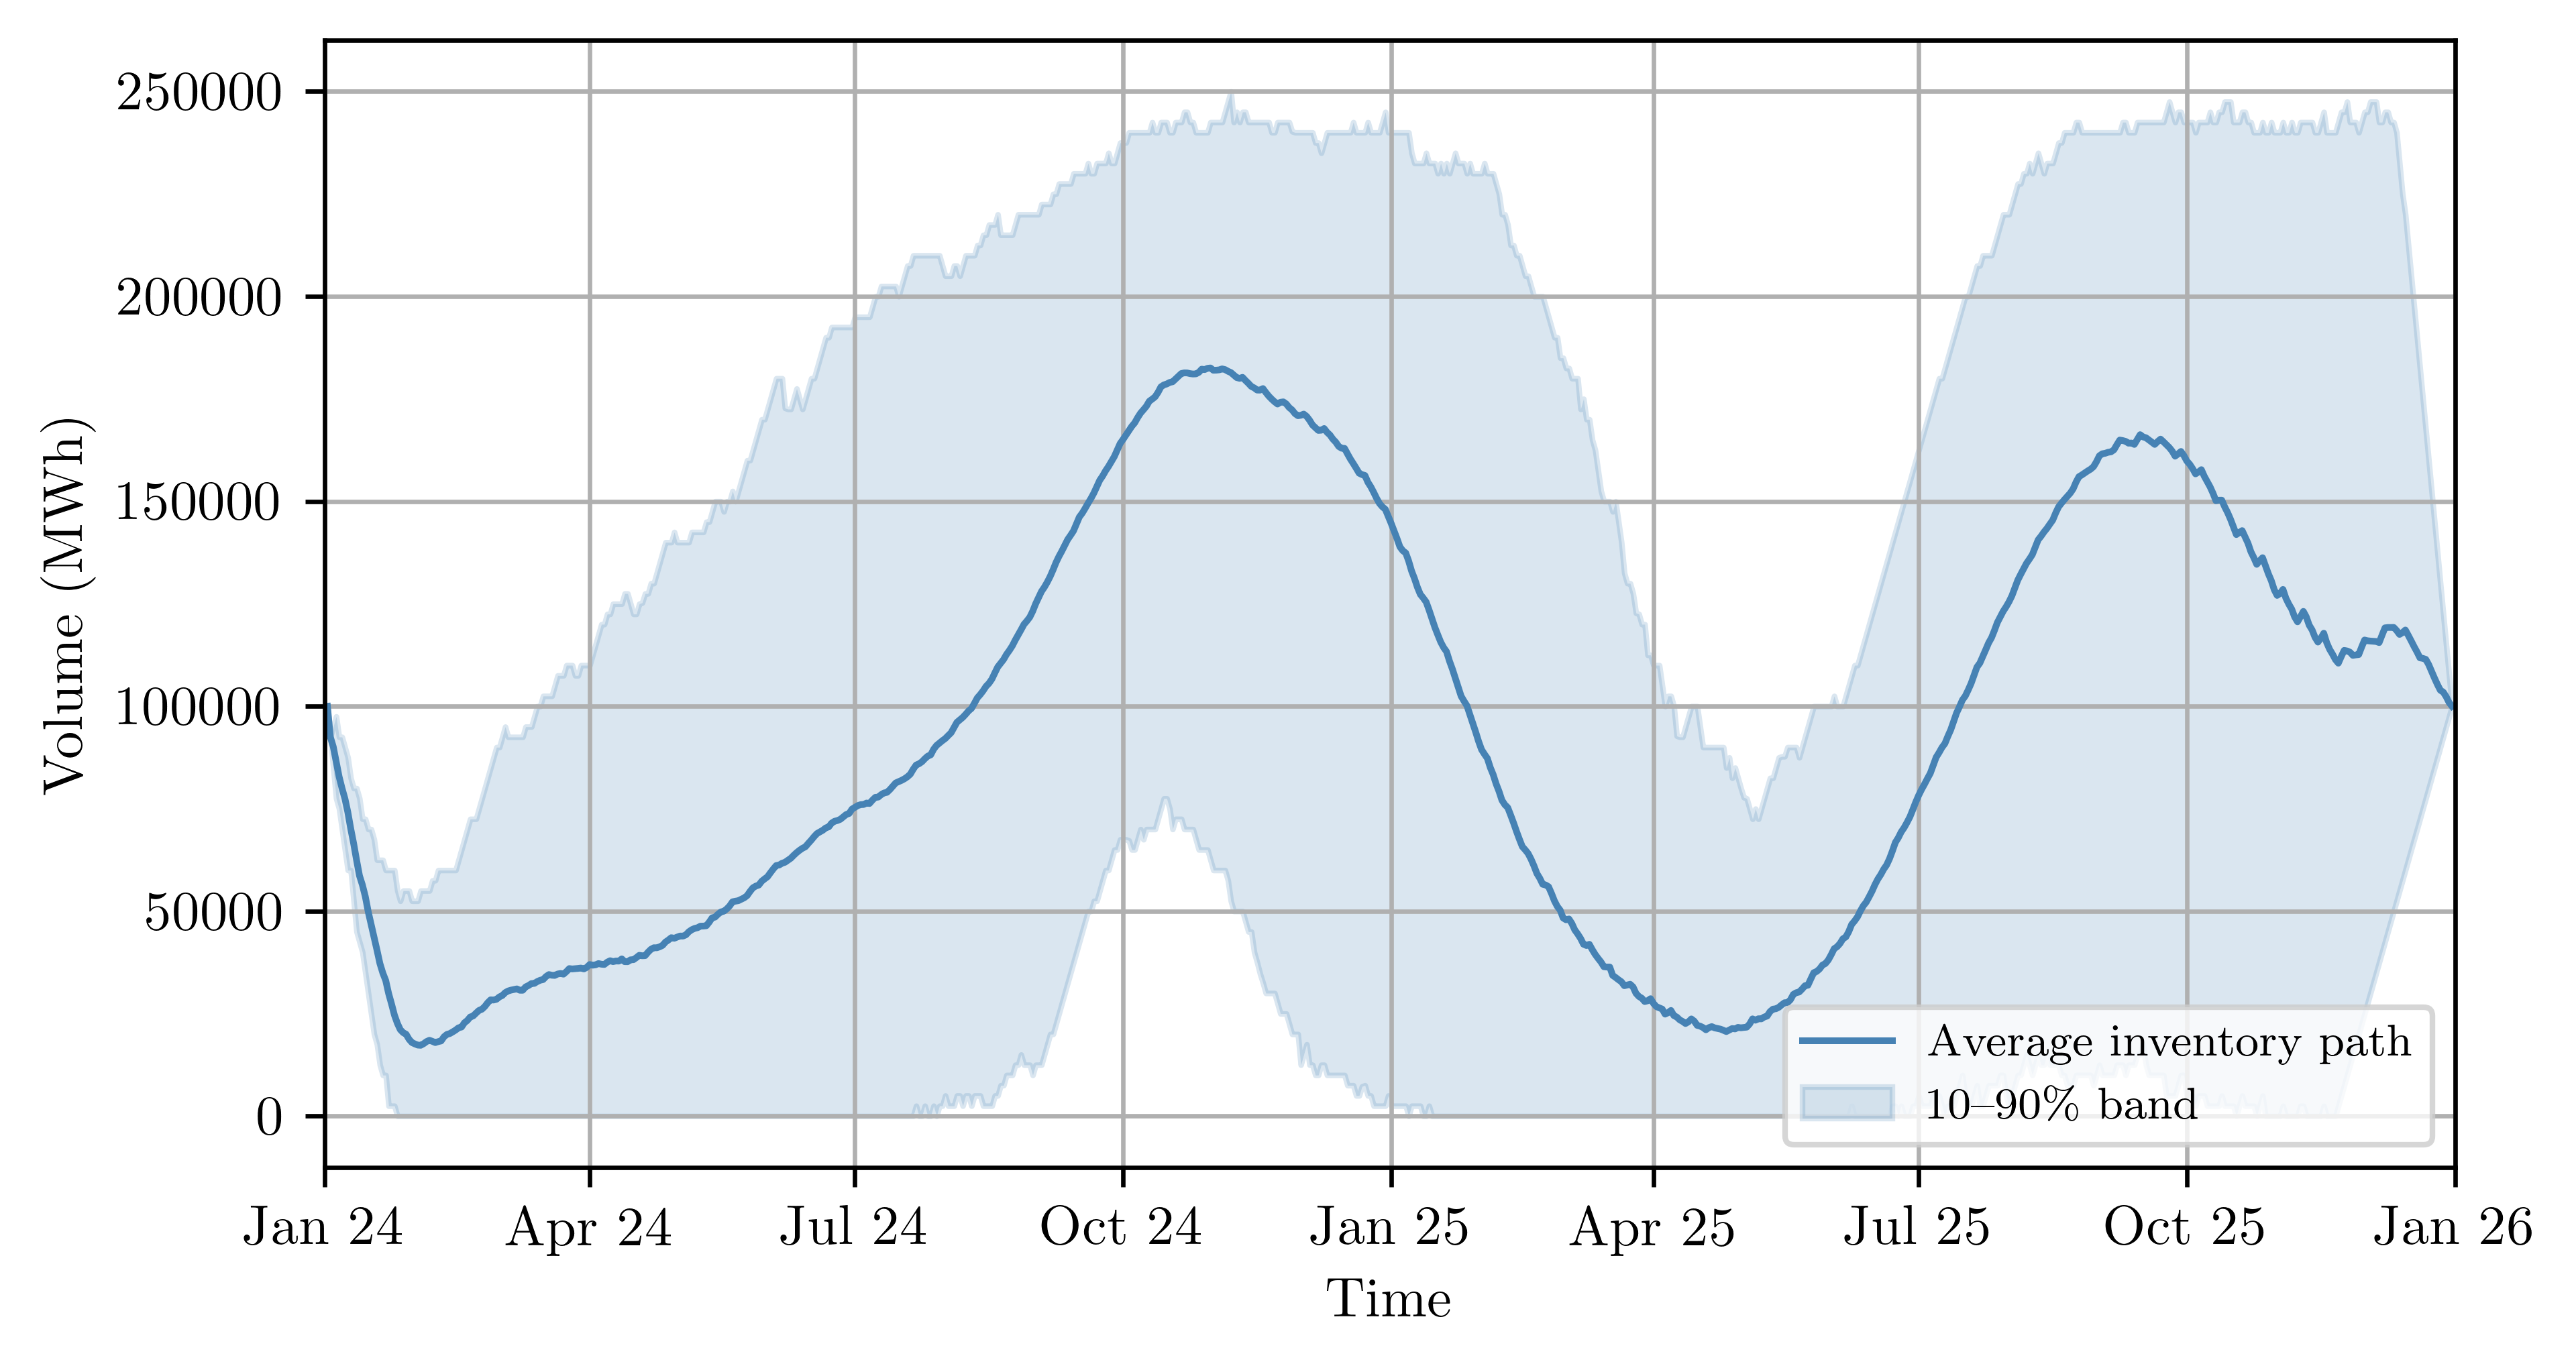

In [2]:
avg_path = v_path.mean(axis=1)
p10      = np.percentile(v_path, 10, axis=1)
p90      = np.percentile(v_path, 90, axis=1)

# Convert numpy datetime64 dates to pandas for plotting
dates_pd = pd.DatetimeIndex(dates)

x_start = pd.Timestamp("2024-01-01")
x_end   = pd.Timestamp("2026-01-01")

# ---- Plot ----
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif":  ["Computer Modern Roman"],
})

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

# Inventory paths
ax.plot(dates_pd, avg_path, color="steelblue", lw=1.2,
        label="Average inventory path")
ax.fill_between(dates_pd, p10, p90, alpha=0.2, color="steelblue",
                label=r"10--90\% band")

# vmax is a true step function — plot on dense grid so steps fall on correct dates
# ax.step(dense_dates, vmax_dense, where="post", color="firebrick",
        # lw=0.9, ls="--", label=r"$v_{\max}(t)$")

# vmin should also be plotted on the daily calendar grid if enabled.
# ax.plot(dense_dates, vmin_dense, color="darkorange",
#         lw=0.9, ls="--", label=r"$v_{\min}(t)$")

ax.set_xlabel("Time")
ax.set_ylabel("Volume (MWh)")
ax.grid(True)

tick_dates = pd.date_range(start=x_start, end=pd.Timestamp("2026-01-01"), freq="3MS")
ax.set_xlim(x_start, x_end)
ax.set_xticks([mdates.date2num(d) for d in tick_dates])
ax.set_xticklabels([d.strftime("%b %y") for d in tick_dates])


ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.savefig("../../fig/Plots/MLP_realised_paths.png")
plt.show()


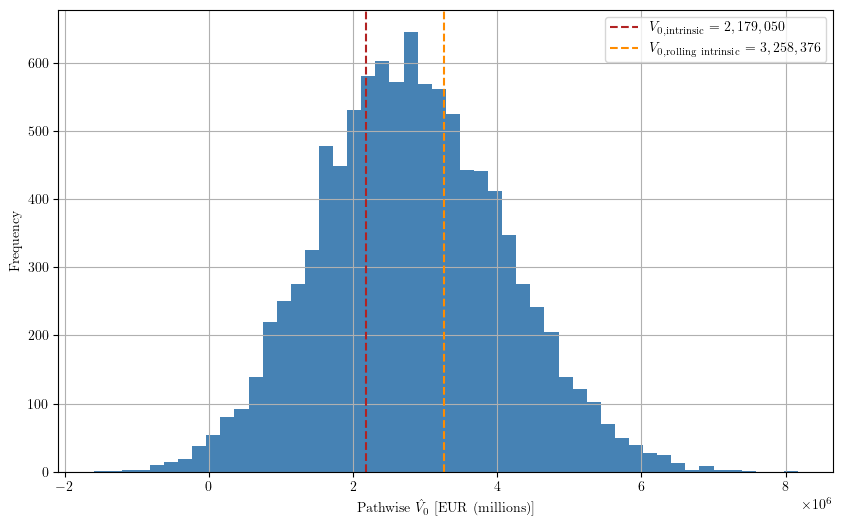

In [3]:
# Calculate V0_hat_pathwise for each path using v_path and S_sim
dv_path = np.diff(v_path, axis=0)            # inventory change from t to t+1
cashflow = -S_sim[:-1] * dv_path            # buy -> negative, sell -> positive

# Discount each calendar-day step back to time 0.
disc_to_0 = np.concatenate(([1.0], np.cumprod(disc_arr[:-1])))
V0_hat_pathwise = np.sum(disc_to_0[:, None] * cashflow, axis=0)

V0_intrinsic =   2179050.15
V0_rolling_intrinsic =    3258376.15 

# Plot frequency of V0_hat_pathwise
plt.figure(figsize=(10, 6))
plt.hist(V0_hat_pathwise, bins=50, alpha=1, color = "steelblue")
plt.axvline(V0_intrinsic, color="firebrick", linestyle="--", label=fr"$V_{{0,\mathrm{{intrinsic}}}} = {V0_intrinsic:,.0f}$")
plt.axvline(V0_rolling_intrinsic, color="darkorange", linestyle="--", label=fr"$V_{{0,\mathrm{{rolling\ intrinsic}}}} = {V0_rolling_intrinsic:,.0f}$")
plt.xlabel("Pathwise $\\hat{V}_0$ [EUR (millions)]")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.savefig("../../fig/Plots/MLP_V0_hat_distribution.png")
plt.show()


In [4]:
# ============================================================
# Out-of-sample valuation using stored MLP models
# ============================================================
def oos_value_from_model_store(S_test: np.ndarray, model_store: list) -> float:
    """
    Evaluate V0 out-of-sample via forward simulation.

    The MLP continuation-value models (model_store) come from a separate
    training run on S_train. Here we roll the trained policy forward on fresh
    test paths S_test - no new training is performed - recording the realised
    cashflows at each step and discounting them back to t=0.

    This avoids the look-ahead bias of the in-sample backward-DP estimate and
    gives a true lower bound on the storage value.
    """
    M = S_test.shape[1]

    C_hat_fine_buf = np.empty((M, Nf), dtype=np.float64)
    n_path_idx = np.empty((T + 1, M), dtype=np.int32)
    forward_simulate_paths_mlp(n_path_idx, S_test, model_store, C_hat_fine_buf)

    # Realised cashflow at step t: sell/buy (v_{t+1} - v_t) MWh at price S_t.
    # Injection (dv > 0) costs -S_t * dv; withdrawal (dv < 0) earns -S_t * dv.
    dv_paths = v_fine[n_path_idx[1:]] - v_fine[n_path_idx[:-1]]   # (T, M)
    cf = -S_test[:T] * dv_paths                                   # (T, M)

    # Cumulative discount from t=0: cashflow at step t is multiplied by
    # disc_arr[0] * ... * disc_arr[t-1] (cashflow at t=0 is undiscounted).
    cum_disc = np.ones(T, dtype=np.float64)
    cum_disc[1:] = np.cumprod(disc_arr[:-1])

    pv = np.sum(cf * cum_disc[:, None], axis=0)   # (M,)

    # Paths that do not end at nT_f are infeasible - assign terminal penalty.
    at_target = (n_path_idx[T] == nT_f)
    n_failed = int(np.sum(~at_target))
    if n_failed > 0:
        print(f"  OOS: {n_failed}/{M} paths did not reach terminal target.")
    pv[~at_target] = np.nan

    return float(np.nanmean(pv))


# ============================================================
# Run: train on S_sim, evaluate out-of-sample on S_test
# ============================================================
# Fresh test paths - independent seed, same antithetic structure
seed_oos = seed + 1
rng_oos = np.random.default_rng(seed_oos)
n_half_oos = int(np.ceil(n_paths_max / 2))
Z_half_oos = rng_oos.standard_normal(size=(Tn - 1, n_half_oos))
Z_oos = np.concatenate([Z_half_oos, -Z_half_oos], axis=1)[:, :n_paths_max]
S_test = simulate_from_Z(Z_oos, n_paths=n_paths_max, Tn=Tn, t_arr=t_arr,
                         kappa_hat=kappa_hat, sigma_hat=sigma_hat, m_col=m_col)

V0_hat_oos = oos_value_from_model_store(S_test, model_store)
print(f"V0_hat (out-of-sample) = {V0_hat_oos:,.2f}")


V0_hat (out-of-sample) = 2,800,259.54
